# Proyecto Final UD2
#### UD2. Aprendizaxe Supervisada

En este proyecto, los alumnos del módulo de Machine Learning deberán demostrar los conocimientos adquiridos durante la UD2 y aplicar al menos dos algoritmos diferentes de aprendizaje supervisado vistos en clase (KNN, Regresión Lineal, Regresión Logística, Árboles de Decisión (o Randm Forest), SVM).

Para ello, tomaremos como referencia el dataset credit_train.csv y credit_test.csv que contienen la información sobre una campaña de márketing llevada a cabo mediante llamadas teléfonicas para captar clientes que quieran acceder a un crédito.

**Features o Input variables:**

1 - age: edad numérica

2 - job : tipo de trabajo (puede tomar los valores: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : estado civil (puede tomar los valores: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education : nivel de estudios (puede tomar los valores: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: ya tiene un crédito solicitado por defecto? (puede tomar los valores: 'no','yes','unknown')

6 - housing: tiene hipoteca? (puede tomar los valores: 'no','yes','unknown')

7 - loan: tiene una cuenta personal? (puede tomar los valores: 'no','yes','unknown')

8 - contact: tipo de comunicación de contacto (puede tomar los valores: 'cellular','telephone')

9 - month: último mes de contacto (puede tomar los valores: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10 - day_of_week: último día de la semana en el que se le ha contactado (puede tomar los valores: 'mon','tue','wed','thu','fri')

11 - duration: duración del último contacto en segundos (numérico). Importante: este atributo afecta en gran medida a la salida ya que si duration es 0, entonces  la salida es 'no')

12 - campaign: número de veces que se le ha contactado durante la campaña a este cliente (numérico, incluye el último contacto)

13 - pdays: número de días que han pasado desde que el cliente fue contactado por última vez(numérico; 999 significa que no ha sido contactado anteriormente)

14 - previous: número de contactos anteriores a esta campaña a este cliente(numérico)

15 - poutcome: resultado de la última campaña de marketing (categorical: 'failure','nonexistent','success')

16 - emp.var.rate: employment variation rate - quarterly indicator (numérico)

17 - cons.price.idx: IPC - indicador mensual (numérico)

18 - cons.conf.idx: índice de confianza de los consumidores - indicador mensual (numérico)

19 - euribor3m: euribor tasa 3 meses - indicador diario (numérico)

20 - nr.employed: número de trabajadores - indicador en porciones  (numérico)

**Output variable (desired target):**

21 - y: Suscripción al crédito por parte del cliente? (binary: 'yes','no')


#### 1. K-Nearest Neighbors (KNN)

K-Nearest Neighbors es un algoritmo de clasificación (también puede usarse para regresión, pero no es lo habitual). No construye un modelo como tal, sino que utiliza directamente los datos de entrenamiento.

- **Funcionamiento**: para clasificar un nuevo dato, compara ese dato con los ya conocidos, busca los *k* más parecidos y asigna la clase más frecuente entre ellos.
- **Distancia**: normalmente se usa la distancia euclidiana cuando las variables son numéricas.
- **Valor de k**: si *k* es pequeño, el modelo es sensible al ruido; si es grande, pierde precisión y aumenta el coste de cálculo.

---

#### 2. Regresión Lineal (Simple y Múltiple)

La Regresión Lineal se utiliza para predecir valores numéricos a partir de una o varias variables de entrada.

- **Objetivo**: encontrar una relación lineal entre las variables que minimice el error entre los valores reales y los predichos.
- **Salida**: genera valores continuos, por lo que no es adecuada para problemas donde la respuesta es *sí / no*, como en este proyecto.

---

#### 3. Regresión Logística

La Regresión Logística es un modelo diseñado específicamente para problemas de clasificación binaria.

- **Salida**: devuelve una probabilidad entre 0 y 1 que indica la posibilidad de que ocurra el evento (por ejemplo, que un cliente contrate el producto).
- **Clasificación**: esa probabilidad se convierte en una decisión final (*sí* o *no*) aplicando un umbral.
- **Ventaja clave**: es sencilla, rápida y fácil de interpretar.

---

#### 4. Árboles de Decisión y Random Forest

- **Árboles de Decisión**: dividen los datos en función de reglas simples basadas en las variables, hasta llegar a una decisión final.
- **Random Forest**: combina muchos árboles de decisión y une sus resultados para obtener una predicción más fiable.
- **Ventaja principal**: reduce el riesgo de sobreajuste y funciona bien incluso con datos poco limpios.

---

#### 5. Support Vector Machines (SVM)

Support Vector Machine es un algoritmo de aprendizaje supervisado usado principalmente en clasificación.

- **Funcionamiento**: busca separar los datos en grupos de la forma más clara posible.
- **Datos complejos**: puede manejar relaciones no lineales entre variables sin necesidad de transformaciones manuales.
- **Fortaleza**: suele ofrecer muy buen rendimiento en problemas de clasificación exigentes.

---

### Modelos Óptimos Seleccionados para el Proyecto

Dado que la variable objetivo (`y`: *yes / no*) corresponde a un problema de **clasificación binaria**, la Regresión Lineal se descarta.

## 1. Importación de paquetes y dataset

Importación del dataset

In [197]:
# Importing Data Analysis Librarys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from math import sqrt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree, DecisionTreeClassifier, export_graphviz
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
warnings.filterwarnings('ignore')

In [198]:
credit = pd.read_csv("/home/cacelas/Documentos/Proyects/credito/data/raw/credit-train.csv")

credit_test = pd.read_csv("/home/cacelas/Documentos/Proyects/credito/data/raw/credit-test.csv")

## 2.EDA y Visual EDA

In [199]:
credit.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


Comprobamos si existen valores nulos (missing values) que requieran tratamiento y verificamos los tipos de datos de cada columna.

In [200]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null  float64
 1

In [201]:
credit.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='str')

In [202]:
credit.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

In [203]:
credit_test.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
dtype: int64

In [204]:
credit.duplicated().sum()

np.int64(12)

In [205]:
credit_test.duplicated().sum()

np.int64(0)

Analizamos la distribución de las variables numéricas y las relaciones entre ellas para detectar patrones o anomalías (outliers).

#### 2.1 Conocer las variables categóricas

Se examinan las categorías de las variables cualitativas para identificar su cardinalidad y evaluar el método de codificación más adecuado en fases posteriores.

In [206]:
print('Trabajos:\n', credit['job'].unique())

Trabajos:
 <StringArray>
[  'blue-collar',    'technician',    'management',      'services',
       'retired',        'admin.',     'housemaid',    'unemployed',
  'entrepreneur', 'self-employed',       'unknown',       'student']
Length: 12, dtype: str


In [207]:
print('Marital:\n', credit['marital'].unique())

Marital:
 <StringArray>
['married', 'single', 'divorced', 'unknown']
Length: 4, dtype: str


In [208]:
print('Education:\n', credit['education'].unique())

Education:
 <StringArray>
[           'basic.4y',             'unknown',   'university.degree',
         'high.school',            'basic.9y', 'professional.course',
            'basic.6y',          'illiterate']
Length: 8, dtype: str


In [209]:
print('Default:\n', credit['default'].unique())
print('Housing:\n', credit['housing'].unique())
print('Loan:\n', credit['loan'].unique())

Default:
 <StringArray>
['unknown', 'no', 'yes']
Length: 3, dtype: str
Housing:
 <StringArray>
['yes', 'no', 'unknown']
Length: 3, dtype: str
Loan:
 <StringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str


#### 2.2 Conocer las variables numericas
Se estudia la distribución de las variables numéricas para detectar asimetrías, valores extremos y posibles transformaciones necesarias antes del modelado.

In [210]:
print('Min edad: ', credit['age'].max())
print('Max edad: ', credit['age'].min())
print('Valores Nulos: ', credit['age'].isnull().any())

Min edad:  98
Max edad:  17
Valores Nulos:  False


In [211]:

print('Min edad: ', credit['age'].max())
print('Max edad: ', credit['age'].min())
print('Valores Nulos: ', credit['age'].isnull().any())

Min edad:  98
Max edad:  17
Valores Nulos:  False


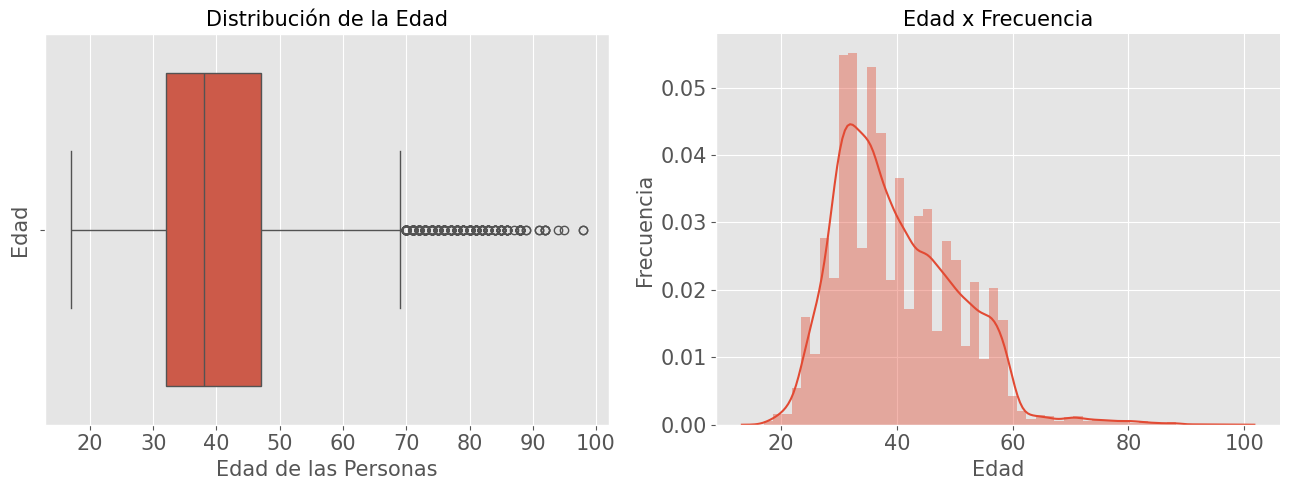

In [212]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13, 5))

# Gráfico 1: Diagrama de Caja (Boxplot)
sns.boxplot(x = 'age', data = credit, orient = 'v', ax = ax1)
ax1.set_xlabel('Edad de las Personas', fontsize=15)
ax1.set_ylabel('Edad', fontsize=15)
ax1.set_title('Distribución de la Edad', fontsize=15)
ax1.tick_params(labelsize=15)

# Gráfico 2: Histograma de distribución
sns.distplot(credit['age'], ax = ax2)
sns.despine(ax = ax2)
ax2.set_xlabel('Edad', fontsize=15)
ax2.set_ylabel('Frecuencia', fontsize=15)
ax2.set_title('Edad x Frecuencia', fontsize=15)
ax2.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

Se analiza la distribución de la edad para detectar posibles valores atípicos y comprobar si existe una relación evidente con la variable objetivo. La distribución es asimétrica, con mayor concentración en edades medias, y no se observan valores extremos que justifiquen su eliminación. A simple vista no se aprecia una relación fuerte con la variable objetivo, por lo que será el modelo el encargado de capturar posibles efectos no lineales.


In [213]:
# Cuartiles
print('1º Cuartil: ', credit['age'].quantile(q = 0.25))
print('2º Cuartil: ', credit['age'].quantile(q = 0.50))
print('3º Cuartil: ', credit['age'].quantile(q = 0.75))
print('4º Cuartil: ', credit['age'].quantile(q = 1.00))

print('Edades por encima de: ', credit['age'].quantile(q = 0.75) + 
                      1.5*(credit['age'].quantile(q = 0.75) - credit['age'].quantile(q = 0.25)), 'son outliers')

1º Cuartil:  32.0
2º Cuartil:  38.0
3º Cuartil:  47.0
4º Cuartil:  98.0
Edades por encima de:  69.5 son outliers


In [214]:
print('Numerber of outliers: ', credit[credit['age'] > 69.6]['age'].count())
print('Number of clients: ', len(credit))
#Outliers in %
print('Outliers are:', round(credit[credit['age'] > 69.6]['age'].count()*100/len(credit),2), '%')

Numerber of outliers:  469
Number of clients:  41188
Outliers are: 1.14 %


In [215]:
print('MEDIA:', round(credit['age'].mean(), 1))

print('DESV :', round(credit['age'].std(), 1))

print('CV   :',round(credit['age'].std()*100/credit['age'].mean(), 1), ', Dispersión media alta')

MEDIA: 40.0
DESV : 10.4
CV   : 26.0 , Dispersión media alta


#### 2.3 JOBS

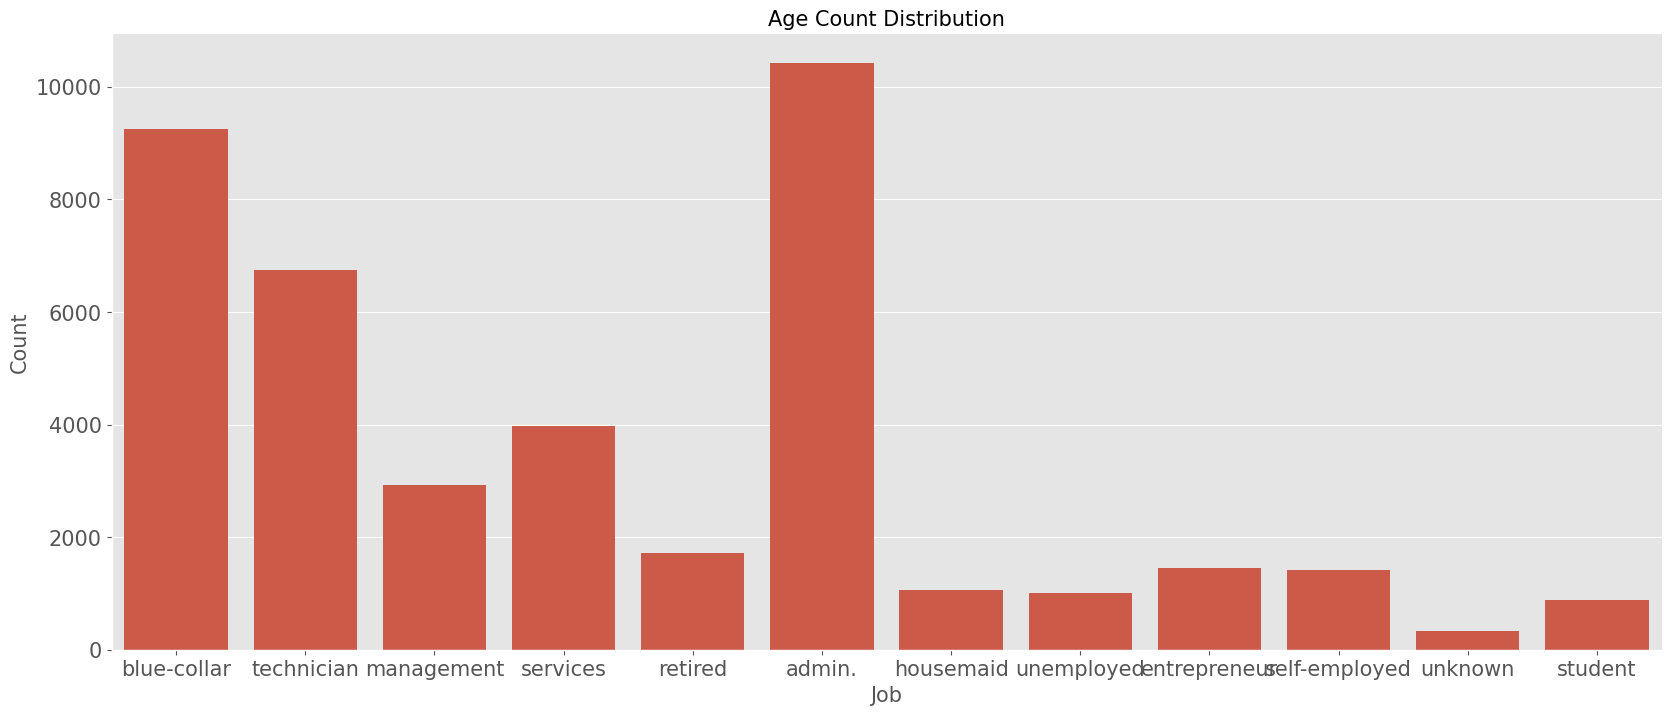

In [216]:
# Qué tipo de trabajos tienen los clientes de este banco;
fig, ax = plt.subplots()
fig.set_size_inches(20, 8)
sns.countplot(x = 'job', data = credit)
ax.set_xlabel('Job', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Age Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

Se estudia la relación entre el tipo de trabajo y la variable objetivo para identificar posibles segmentos con mayor tasa de conversión. Se observan diferencias claras entre categorías, lo que indica que esta variable contiene información relevante para el modelo y justifica su inclusión tras un proceso adecuado de codificación.

#### 2.4 MARITAL

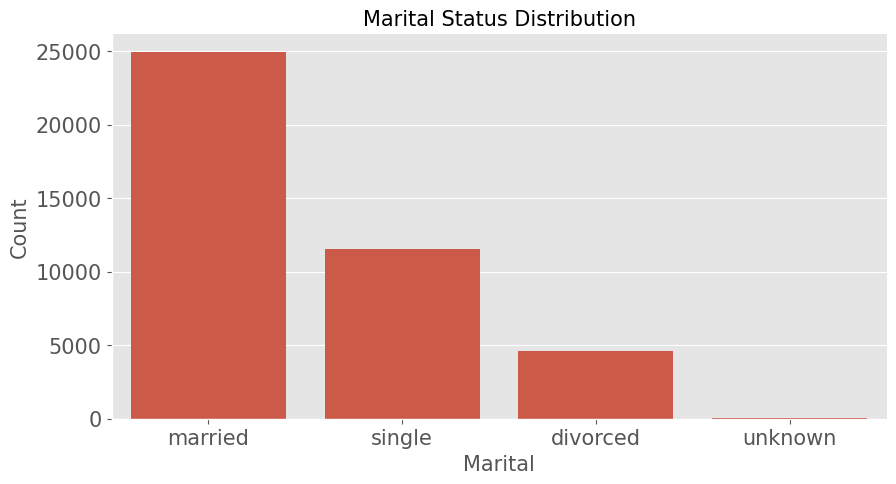

In [217]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
sns.countplot(x = 'marital', data = credit)
ax.set_xlabel('Marital', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Marital Status Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

La gran mayoría son casados (aprox. 25,000), superando por más del doble a los solteros. Esto suele indicar clientes con mayor estabilidad, pero también con más cargas familiares.

#### 2.5 EDUCATION¶

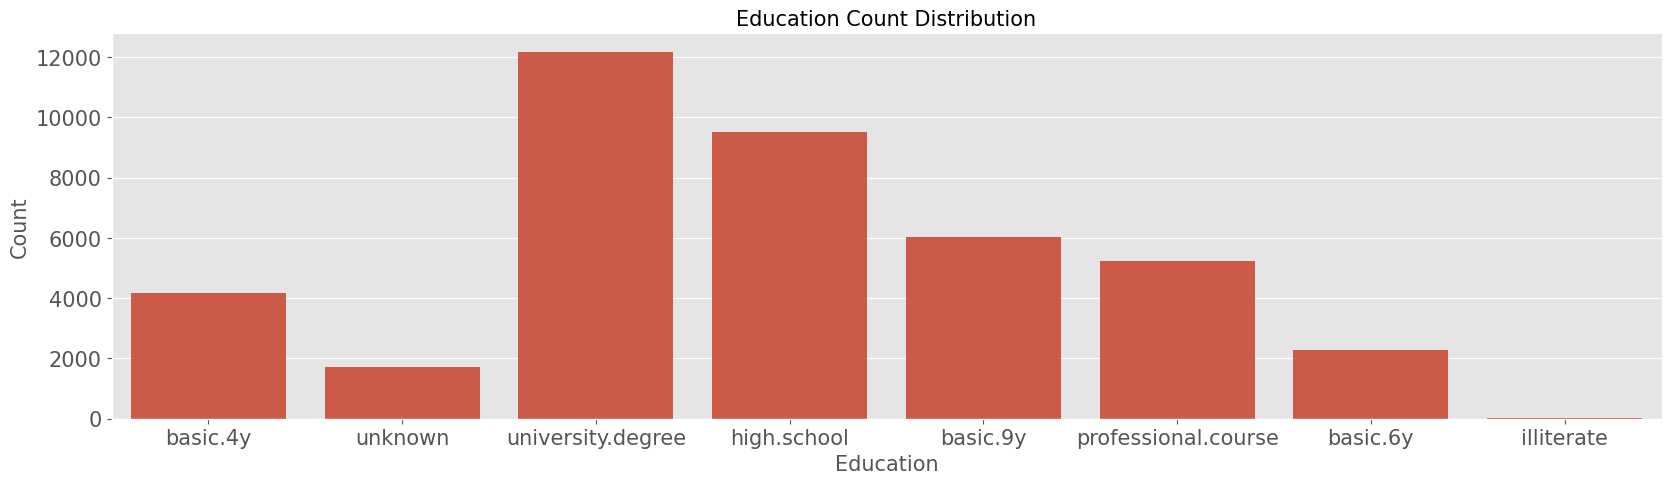

In [218]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
sns.countplot(x = 'education', data = credit)
ax.set_xlabel('Education', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Education Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

El dataset tiene un sesgo claro hacia la educación superior. La categoría university.degree es la más frecuente, seguida de high.school.
Combinado con el gráfico anterior (mayoría casados), esto refuerza la idea de un perfil de cliente de clase media/estable.

#### 2.6. DEFAULT, HOUSING, LOAN

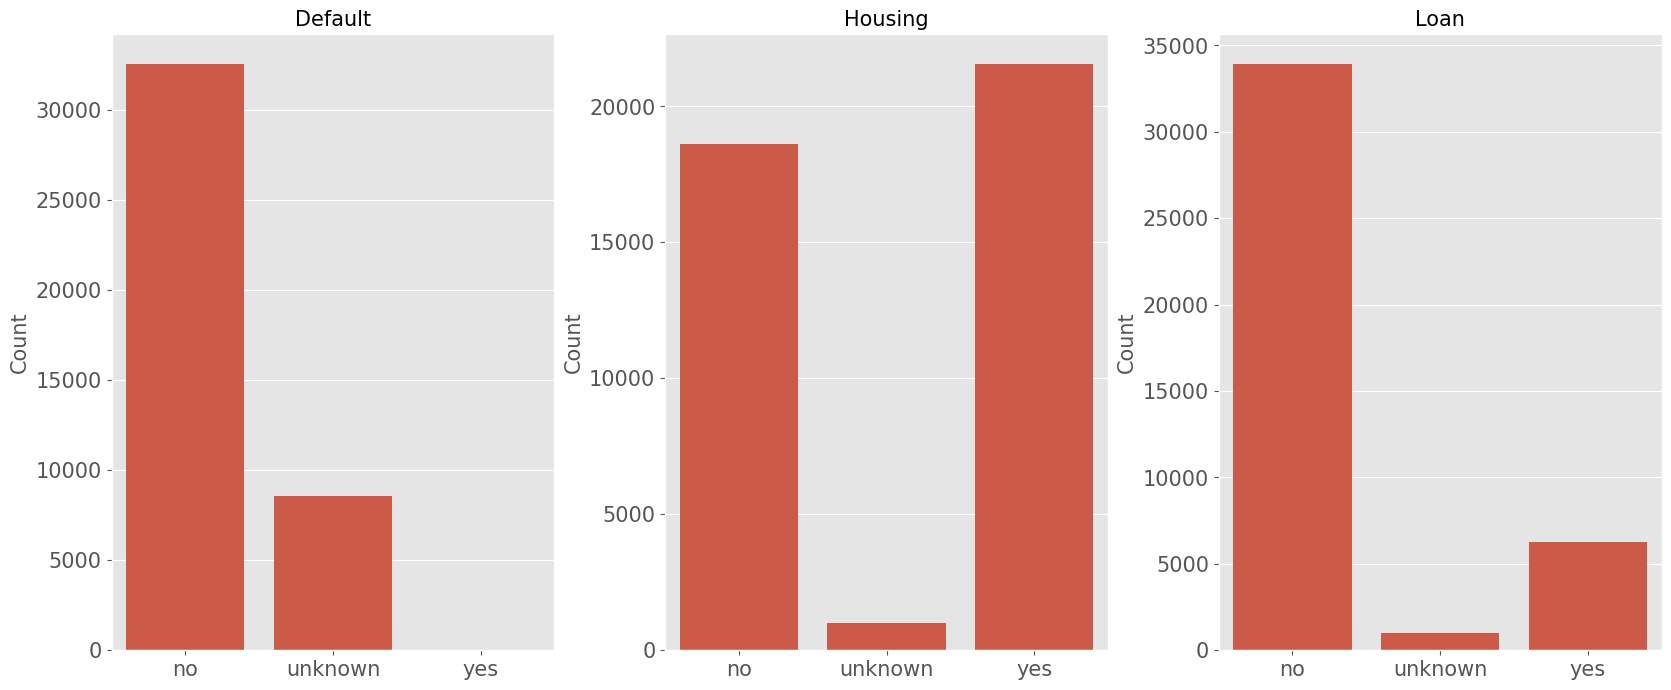

In [219]:
# Default: tiene crédito en incumplimiento?
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20,8))
sns.countplot(x='default', data=credit, ax=ax1, order=['no', 'unknown', 'yes'])
ax1.set_title('Default', fontsize=15)
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=15)
ax1.tick_params(labelsize=15)

# Housing: tiene préstamo hipotecario?
sns.countplot(x='housing', data=credit, ax=ax2, order=['no', 'unknown', 'yes'])
ax2.set_title('Housing', fontsize=15)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=15)
ax2.tick_params(labelsize=15)

# Loan: tiene préstamo personal?
sns.countplot(x='loan', data=credit, ax=ax3, order=['no', 'unknown', 'yes'])
ax3.set_title('Loan', fontsize=15)
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=15)
ax3.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.25)


Bloque Default (Incumplimiento): La barra no es enorme, la barra unknown es significativa (unas 8,500) y la barra yes es invisible (casi cero). El modelo no tendrá suficientes ejemplos de "gente que no paga" (yes) para aprender, y hay demasiados datos desconocidos (unknown) que ensucian esta variable.

Bloque Housing (Hipoteca): Las barras de no y yes tienen alturas comparables, siendo yes (con hipoteca) ligeramente superior (más de 20,000). Muestra que la población está dividida casi a la mitad, lo cual es excelente para que el modelo encuentre patrones claros.

Bloque Loan (Préstamo Personal): La barra no es dominante (cerca de 34,000) frente a una barra yes pequeña (aprox 6,000). La gran mayoría de los clientes no tiene préstamos personales activos. Esto confirma un perfil de cliente conservador o que no suele endeudarse por consumo.

#### 2.7 CONTACT, MONTH, DAY_OF_WEEK

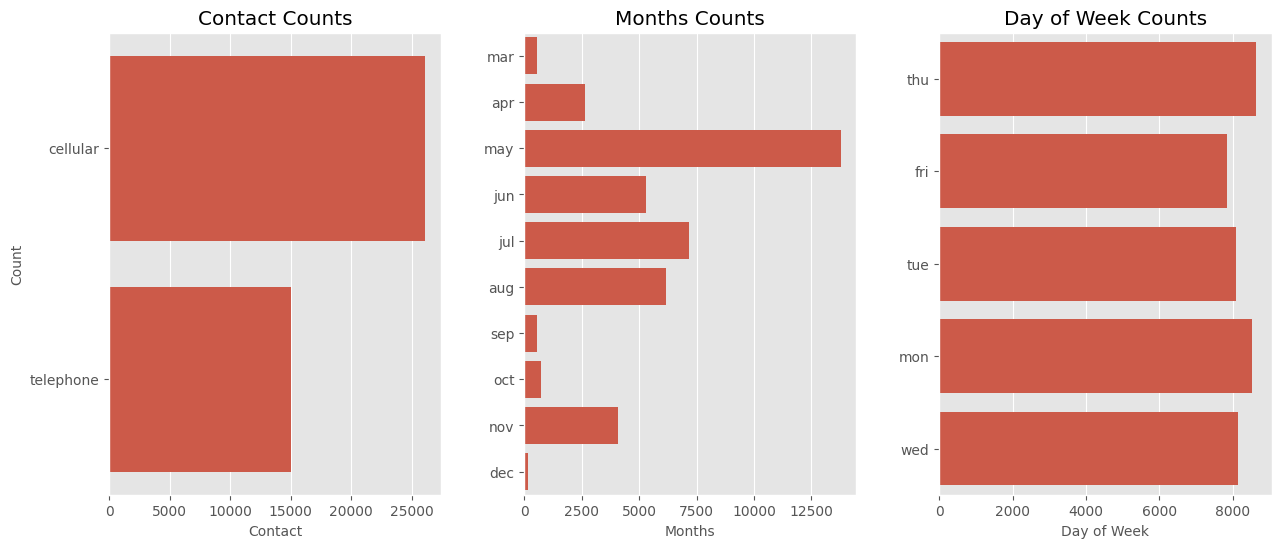

In [220]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (15,6))
sns.countplot(credit['contact'], ax = ax1)
ax1.set_xlabel('Contact', fontsize = 10)
ax1.set_ylabel('Count', fontsize = 10)
ax1.set_title('Contact Counts')
ax1.tick_params(labelsize=10)

sns.countplot(credit['month'], ax = ax2, order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
ax2.set_xlabel('Months', fontsize = 10)
ax2.set_ylabel('')
ax2.set_title('Months Counts')
ax2.tick_params(labelsize=10)

sns.countplot(credit['day_of_week'], ax = ax3)
ax3.set_xlabel('Day of Week', fontsize = 10)
ax3.set_ylabel('')
ax3.set_title('Day of Week Counts')
ax3.tick_params(labelsize=10)

plt.subplots_adjust(wspace=0.25)

Bloque Contacto (Contact): La barra de cellular (móvil) es casi el doble de larga que la de telephone (fijo), con unos 26,000 registros frente a 15,000. La estrategia de contacto es moderna o prioriza los móviles. Al modelar, el tipo de dispositivo podría influir en si la persona contesta o no (la tasa de respuesta suele variar entre fijo y móvil).

Bloque Meses (Months - Estacionalidad): Hay un pico gigante en Mayo (may), que supera por mucho a cualquier otro mes. Los meses de verano (jul, aug, jun) tienen actividad media, mientras que dec, sep, oct y mar son casi nulos. Los datos tienen un sesgo temporal extremo. No es una muestra aleatoria de todo el año; refleja probablemente una campaña masiva específica que ocurrió en mayo.

Bloque Día de la Semana (Day of Week): Todas las barras (mon a fri) son casi idénticas en longitud (alrededor de 8,000 cada una). Es probable que esta variable tenga poco poder predictivo

#### 2.8 VARIABLES INDIVIDUALES 

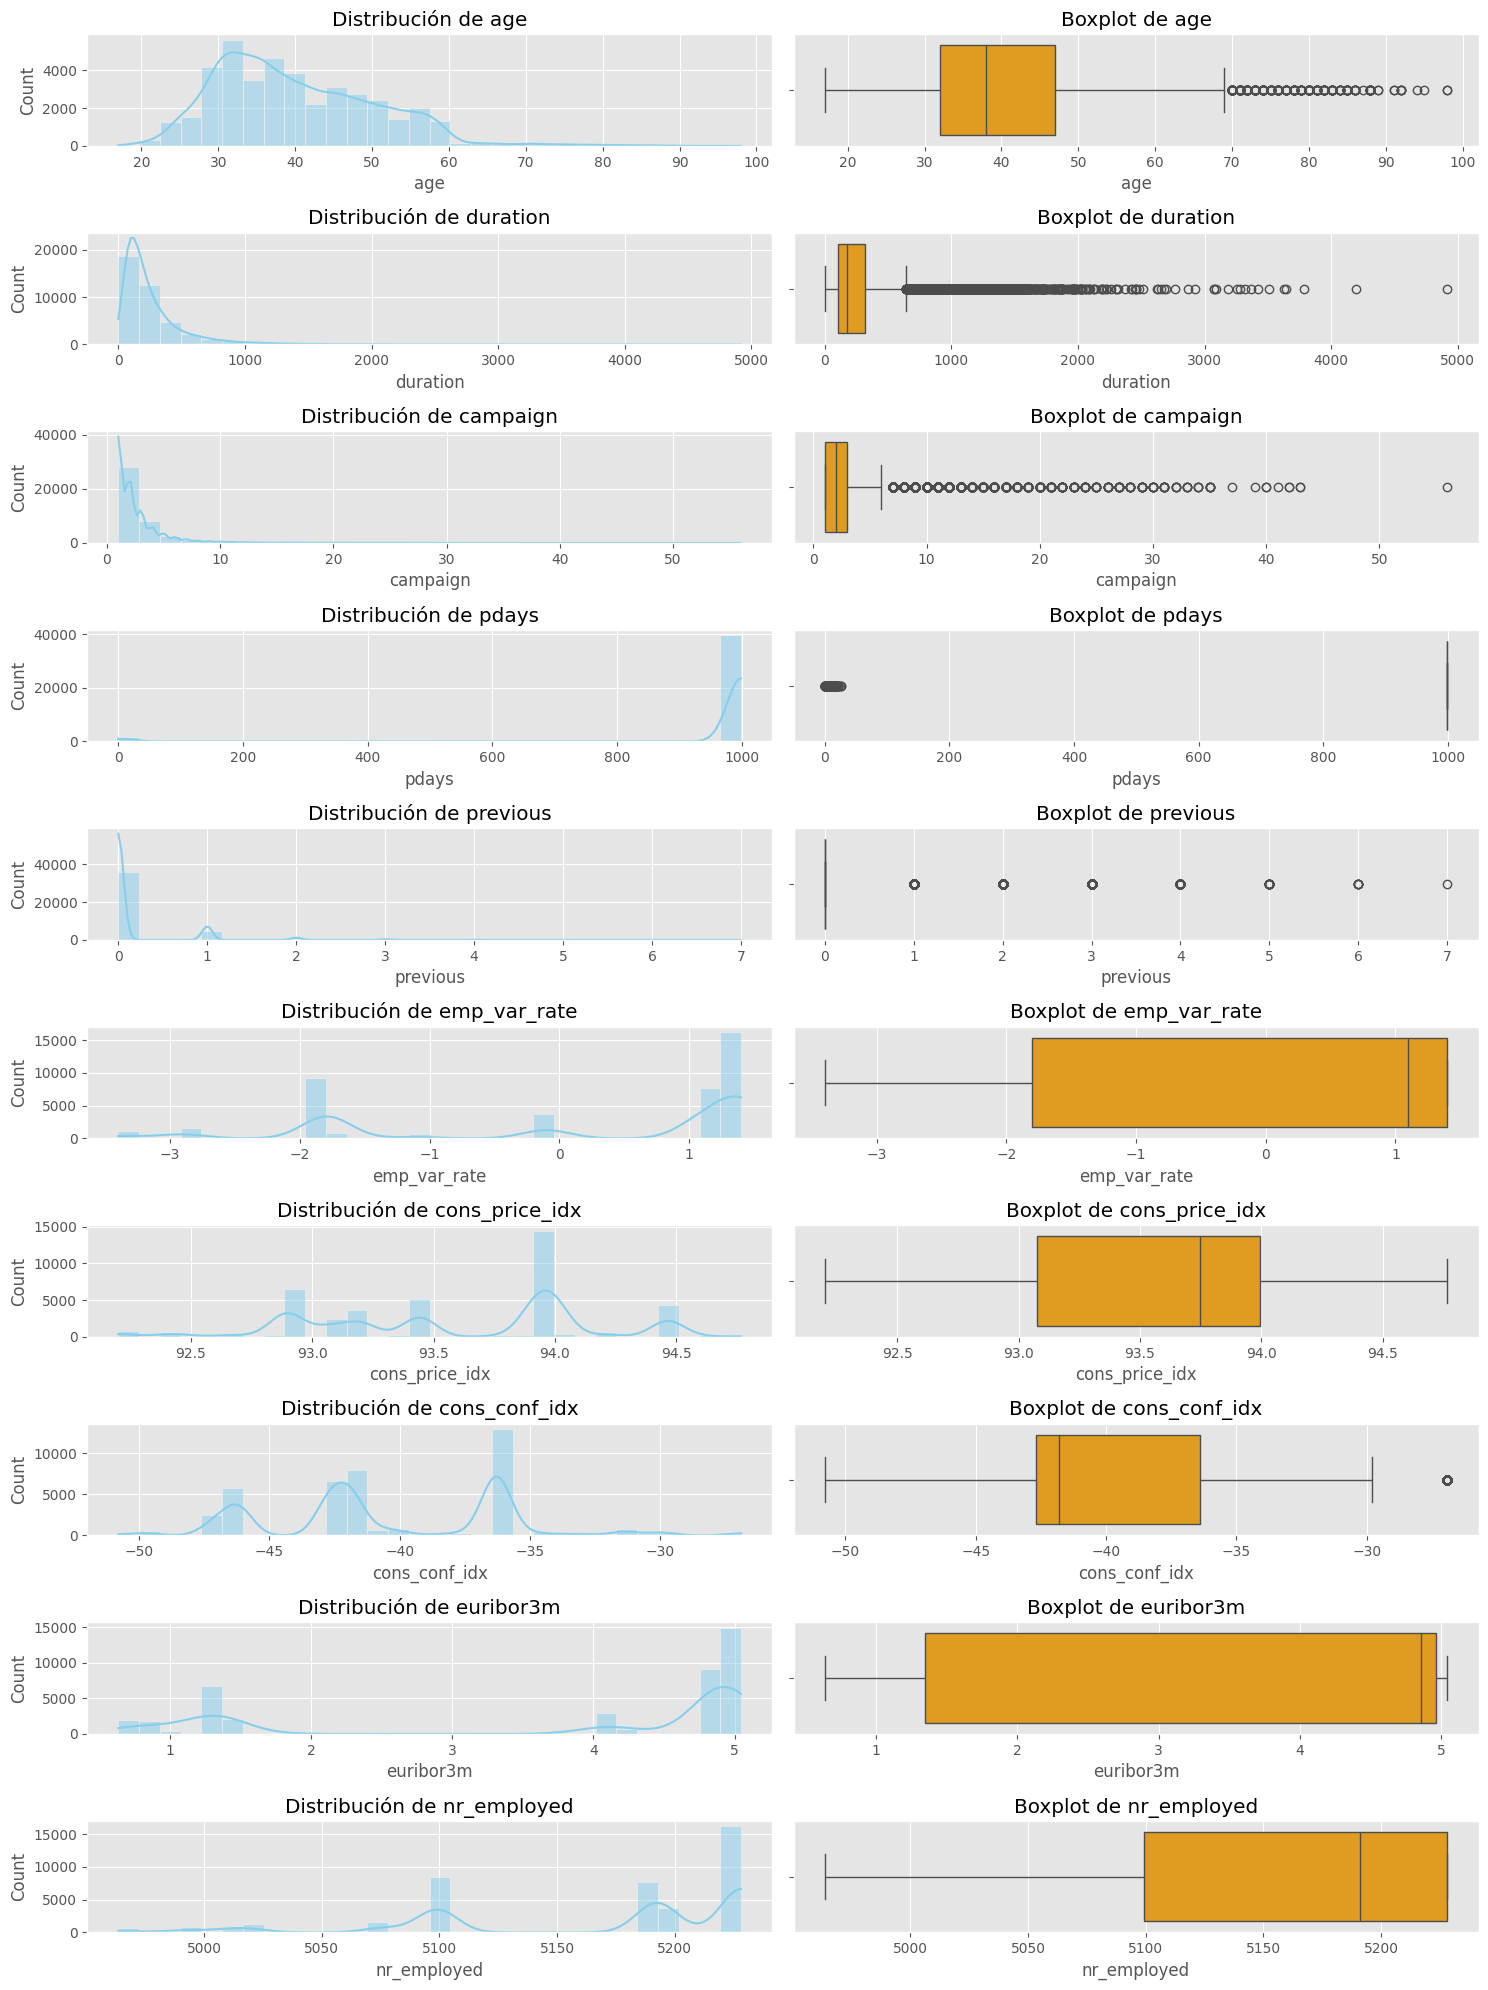

In [221]:
# Definimos las columnas numéricas (excluyendo la target)
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
            'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']

# Configuración de gráficos
plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols):
    # Histograma
    plt.subplot(len(num_cols), 2, 2*i + 1)
    sns.histplot(credit[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribución de {col}')
    
    # Boxplot (para ver outliers)
    plt.subplot(len(num_cols), 2, 2*i + 2)
    sns.boxplot(x=credit[col], color='orange')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

1. Perfil de Edad (age) Observo que la gran mayoría de los clientes se concentra en el rango de los 30 a 40 años, que constituye mi población económicamente más activa. El boxplot revela una cantidad significativa de outliers por encima de los 70 años, esto sugiere que los jubilados son casos atípicos en la muestra y podrían comportarse de manera muy distinta al resto.

2. Contacto Previo (pdays) El histograma de pdays es muy revelador: casi la totalidad de los datos se agrupan en el valor 999.999 significa que no ha sido contactado anteriormente

3. Indicadores Económicos (euribor3m, nr_employed, emp_var_rate) Al analizar las variables macroeconómicas, no veo curvas suaves, sino distribuciones con picos muy marcados y separados. Esto indica que los datos no fueron recolectados de manera uniforme a lo largo del tiempo, sino que reflejan momentos muy específicos de la situación económica (probablemente campañas puntuales).

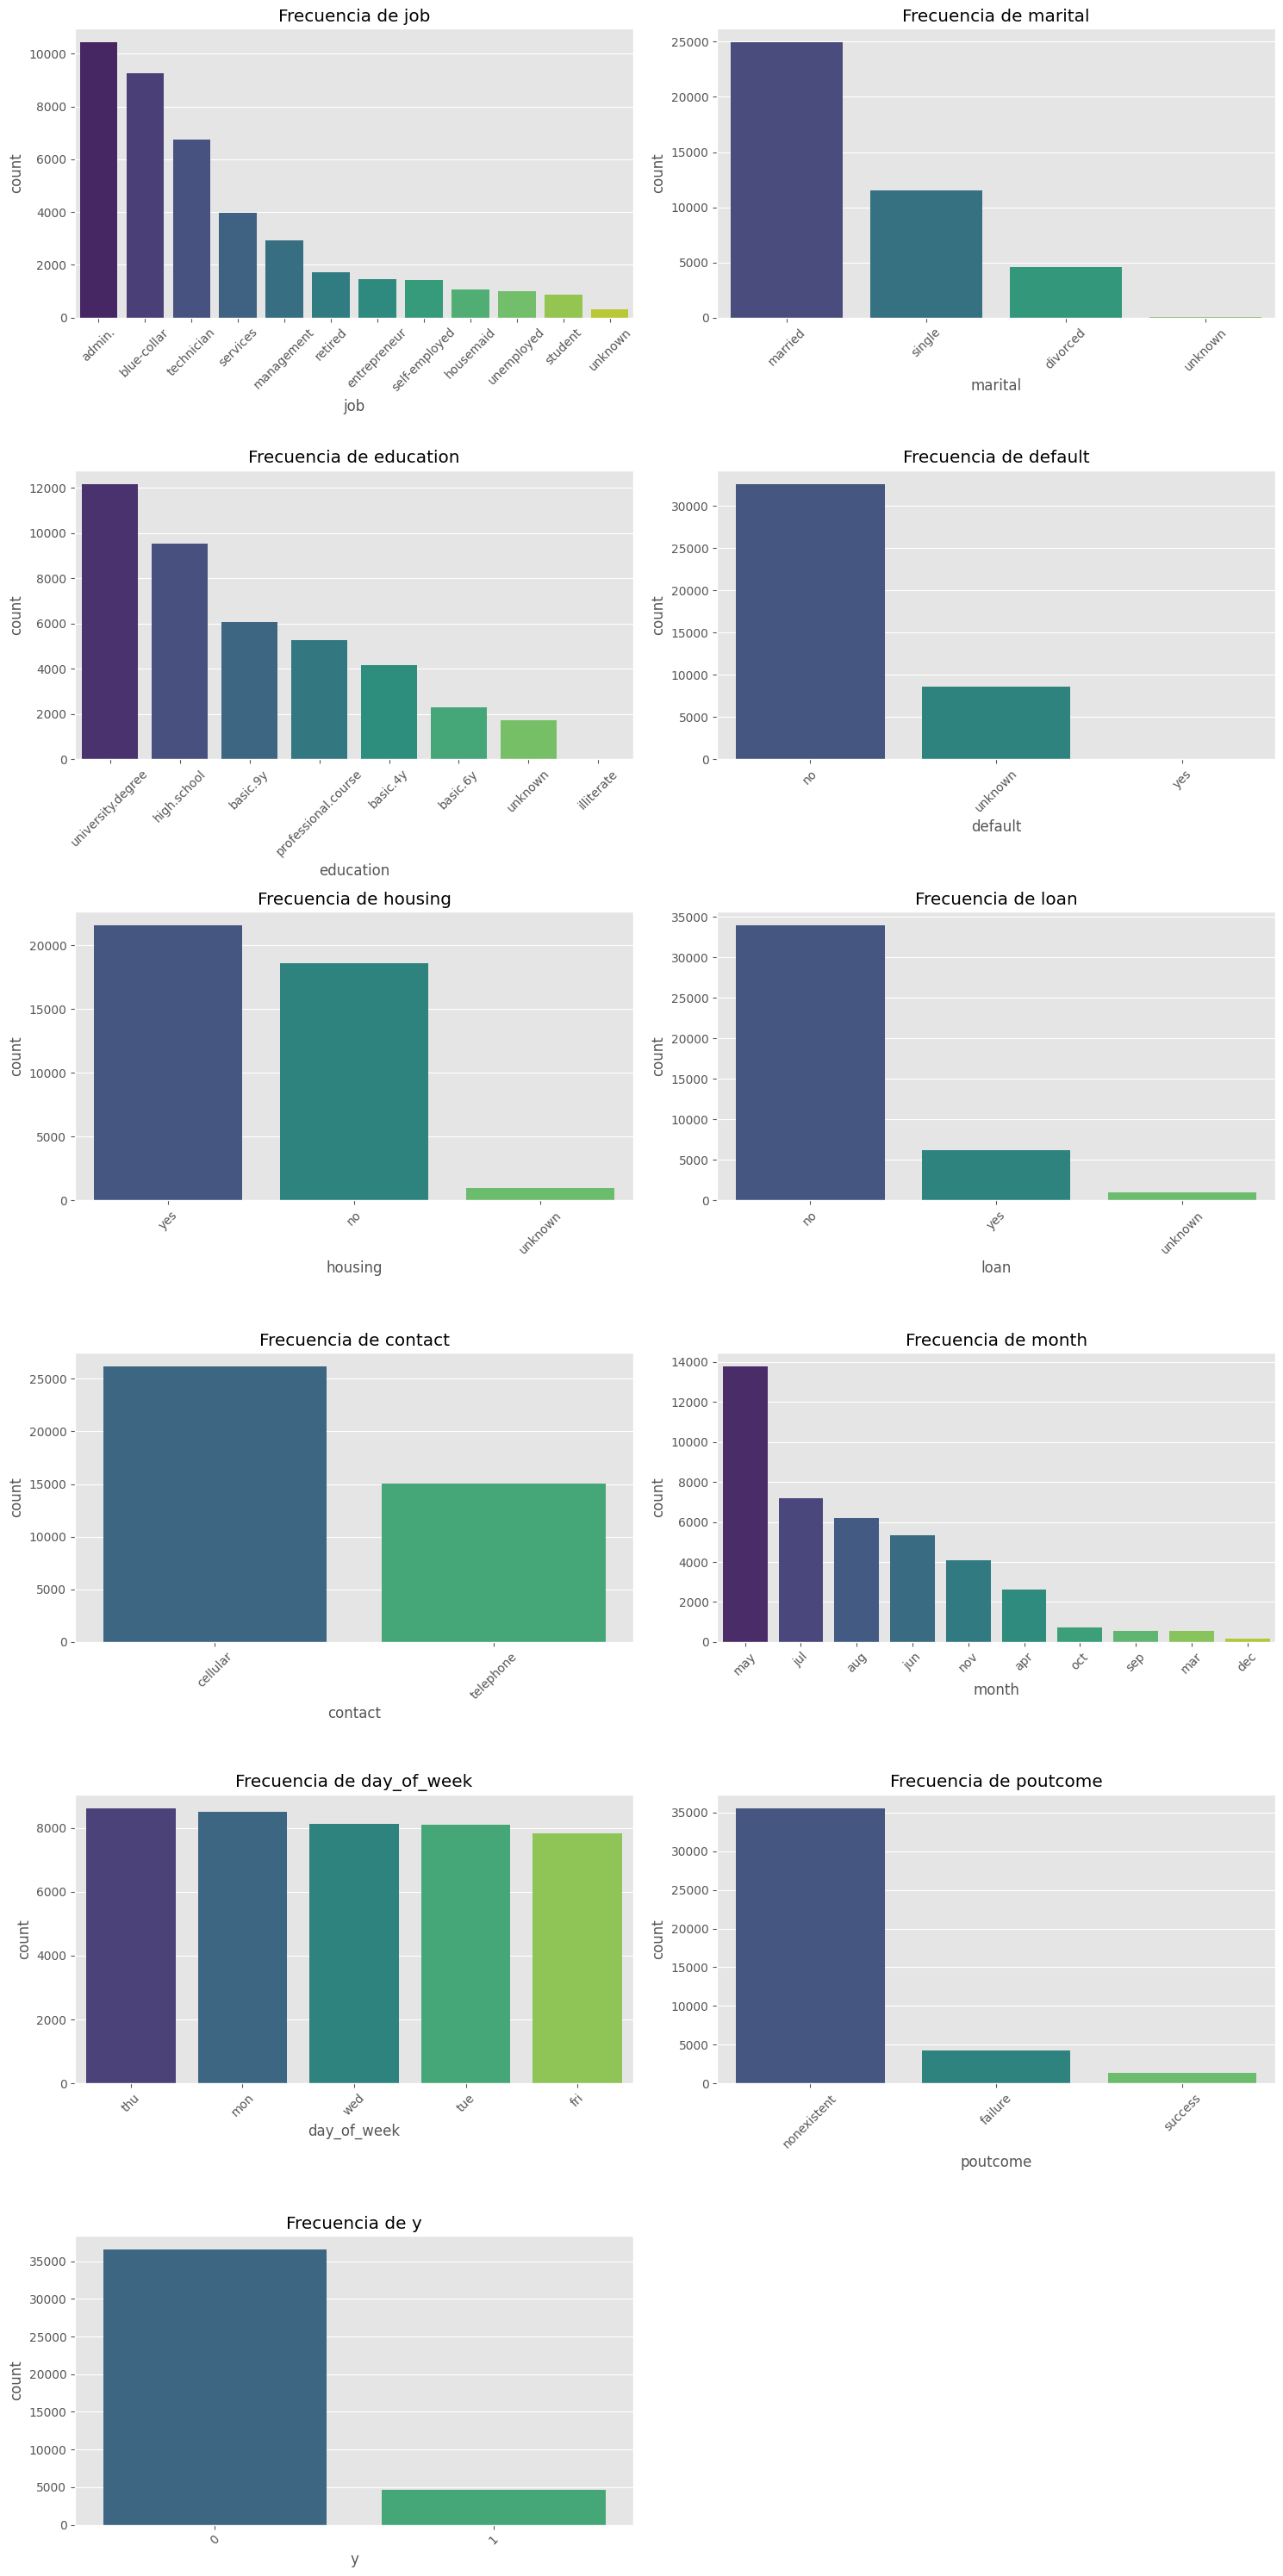

In [222]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome', 'y']

plt.figure(figsize=(15, 30))

for i, col in enumerate(cat_cols):
    plt.subplot(6, 2, i + 1)
    # Ordenamos por conteo para verlo mejor
    sns.countplot(x=credit[col], order=credit[col].value_counts().index, palette='viridis')
    plt.title(f'Frecuencia de {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Perfil del Cliente: Predomina un perfil conservador y estable: personas casadas, con trabajo administrativo y educación superior.

Calidad de Variables: La variable default es prácticamente inútil porque casi no tiene variación (casi nadie tiene impagos), mientras que housing (hipoteca) es la más equilibrada y útil para separar grupos.

Sesgo Temporal: Hay un problema de estacionalidad: la mayoría de los datos son de mayo, lo que sesga la muestra. Por el contrario, el día de la semana es irrelevante (distribución plana).

Target Desbalanceado: La variable objetivo y tiene muchísimos más "no" que "sí". Esto confirma que tendré que usar técnicas de balanceo o métricas específicas (como Recall) en lugar de solo mirar la exactitud (Accuracy).

#### 2.9 Relaciones entre variables

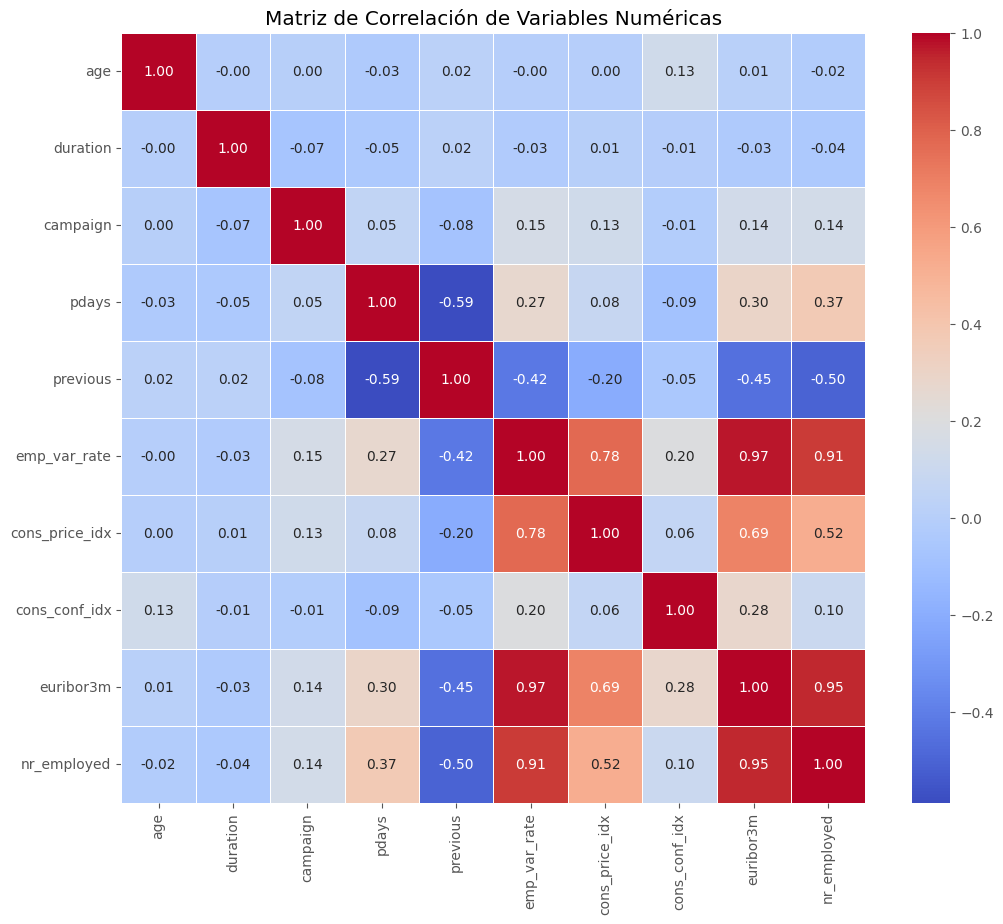

In [223]:
# Calculamos la correlación solo de las columnas numéricas
plt.figure(figsize=(12, 10))
corr_matrix = credit[num_cols].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Alerta de Multicolinealidad (Bloque Rojo Inferior): He notado que las variables económicas (emp_var_rate, euribor3m y nr_employed) están extremadamente correlacionadas entre sí (valores de 0.95 a 0.97).

Relación Histórica (pdays vs previous): Existe una correlación negativa fuerte (-0.59) entre estas dos. Es lógico: si ya hubo contactos previos (previous), la variable de días (pdays) deja de ser 999. Esto confirma que ambas miden la "temperatura" de la relación con el cliente.

Independencia de la Edad y Duración: Me llama la atención que age y duration tienen colores muy claros (correlación casi 0) con el resto. Son variables muy "independientes", lo cual es bueno porque aportan información única que no se solapa con los datos económicos.

In [224]:
print('Impago de crédito:'
      '\n No tiene impago:'          , credit[credit['default'] == 'no']     ['age'].count(),
      '\n Impago desconocido:'       , credit[credit['default'] == 'unknown']['age'].count(),
      '\n Sí tiene impago:'          , credit[credit['default'] == 'yes']    ['age'].count())


Impago de crédito:
 No tiene impago: 32588 
 Impago desconocido: 8597 
 Sí tiene impago: 3


In [225]:
print('Préstamo hipotecario:'
      '\n No tiene préstamo:'           , credit[credit['housing'] == 'no']['age'].count(),
      '\n Préstamo desconocido:'        , credit[credit['housing'] == 'unknown']['age'].count(),
      '\n Sí tiene préstamo:'           , credit[credit['housing'] == 'yes']['age'].count())


Préstamo hipotecario:
 No tiene préstamo: 18622 
 Préstamo desconocido: 990 
 Sí tiene préstamo: 21576


In [226]:
print('Préstamo personal:'
      '\n No tiene préstamo:'     , credit[credit['loan'] == 'no']['age'].count(),
      '\n Préstamo desconocido:'        , credit[credit['loan'] == 'unknown']['age'].count(),
      '\n Sí tiene préstamo:'           , credit[credit['loan'] == 'yes']['age'].count())


Préstamo personal:
 No tiene préstamo: 33950 
 Préstamo desconocido: 990 
 Sí tiene préstamo: 6248


## 3. Preprocessing data


In [227]:
credit.drop_duplicates(inplace=True)

#### 3.1 Bank Client Categorical Treatment
- Jobs, Marital, Education, Default, Housing, Loan. Converting to continuous due the feature scaling will be apllyed later

In [228]:
# Education tiene un orden lógico, lo convertimos manualmente
education_mapping = {
    'illiterate': 1,
    'basic.4y': 2,
    'basic.6y': 3,
    'basic.9y': 4,
    'high.school': 5,
    'professional.course': 6,
    'university.degree': 7,
    'unknown': 8
}
#--------------------------Preparacion train-------------------------
credit['education'] = credit['education'].map(education_mapping)
#--------------------------Preparacion test--------------------------
credit_test['education'] = credit_test['education'].map(education_mapping)

In [229]:
labelencoder_X = LabelEncoder()
#--------------------------Preparacion train-------------------------
credit['job']      = labelencoder_X.fit_transform(credit['job']) 
credit['marital']  = labelencoder_X.fit_transform(credit['marital']) 
credit['education']= labelencoder_X.fit_transform(credit['education']) 
credit['default']  = labelencoder_X.fit_transform(credit['default']) 
credit['housing']  = labelencoder_X.fit_transform(credit['housing']) 
credit['loan']     = labelencoder_X.fit_transform(credit['loan']) 
credit['poutcome'] = labelencoder_X.fit_transform(credit['poutcome']) 

#--------------------------Preparacion test--------------------------
credit_test['job']      = labelencoder_X.fit_transform(credit_test['job']) 
credit_test['marital']  = labelencoder_X.fit_transform(credit_test['marital']) 
credit_test['education']= labelencoder_X.fit_transform(credit_test['education']) 
credit_test['default']  = labelencoder_X.fit_transform(credit_test['default']) 
credit_test['housing']  = labelencoder_X.fit_transform(credit_test['housing']) 
credit_test['loan']     = labelencoder_X.fit_transform(credit_test['loan']) 
credit_test['poutcome'] = labelencoder_X.fit_transform(credit_test['poutcome']) 

In [230]:
credit_cat = credit.iloc[:, list(range(0,7)) + [14]]

In [231]:
print(credit.shape)
credit_cat.head()

(41176, 21)


,age,job,marital,education,default,housing,loan,poutcome
0,44,1,1,1,1,2,0,1
1,53,9,1,7,0,0,0,1
2,28,4,2,6,0,2,0,2
3,39,7,1,4,0,0,0,1
4,55,5,1,1,0,2,0,2


#### 3.2 Related with the last contact of the current campaign
- Treat categorical, see those values
- group continuous variables if necessary


In [232]:
from sklearn.preprocessing import LabelEncoder

labelencoder_X = LabelEncoder()
#--------------------------Preparacion train--------------------------
credit['contact']     = labelencoder_X.fit_transform(credit['contact'])
credit['month']       = labelencoder_X.fit_transform(credit['month'])
credit['day_of_week'] = labelencoder_X.fit_transform(credit['day_of_week'])

#--------------------------Preparacion test--------------------------
credit_test['contact']     = labelencoder_X.fit_transform(credit_test['contact'])
credit_test['month']       = labelencoder_X.fit_transform(credit_test['month'])
credit_test['day_of_week'] = labelencoder_X.fit_transform(credit_test['day_of_week'])

In [233]:
credit_temp = credit.iloc[: , 7:11]
credit_temp.head()

,contact,month,day_of_week,duration
0,0,1,2,210
1,0,7,0,138
2,0,4,2,339
3,0,0,0,185
4,0,1,0,137


In [234]:
credit.isnull().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
pdays             False
previous          False
poutcome          False
emp_var_rate      False
cons_price_idx    False
cons_conf_idx     False
euribor3m         False
nr_employed       False
y                 False
dtype: bool

In [235]:
credit_test.isnull().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
pdays             False
previous          False
poutcome          False
emp_var_rate      False
cons_price_idx    False
cons_conf_idx     False
euribor3m         False
nr_employed       False
dtype: bool

In [236]:
print("Tipo de contacto: \n", credit['contact'].unique())
print("\nEn qué meses se realizó esta campaña: \n", credit['month'].unique())
print("\nQué días de la semana se realizó esta campaña: \n", credit['day_of_week'].unique())

Tipo de contacto: 
 [0 1]

En qué meses se realizó esta campaña: 
 [1 7 4 0 3 6 8 5 9 2]

Qué días de la semana se realizó esta campaña: 
 [2 0 3 1 4]


3.3 Borrar variables

In [237]:
cols_to_drop = [
    'duration',       
    'default',        
    'nr_employed',   
    'emp_var_rate', 
    'day_of_week',
    'pdays' 
]

# Eliminamos las columnas del train
credit = credit.drop(columns=cols_to_drop)

# Eliminamos las columnas del test
credit_test = credit_test.drop(columns=cols_to_drop)

## 4. Creación del modelo y división del dataset

In [238]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definición de X e y
X = credit.drop('y', axis=1)
y = credit['y']

In [239]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

El conjunto de datos se divide en entrenamiento y prueba para evaluar el rendimiento del modelo sobre datos no vistos y evitar sobreajuste.

In [240]:
print("Training set shape", X_train.shape)
print("Test set shape", X_test.shape)

Training set shape (32940, 14)
Test set shape (8236, 14)


### 5. Entrenamiento 

#### Knn

calculo de la mejor k

([<matplotlib.axis.XTick at 0x7f1517aa7890>,
 [Text(0, 0, '0'), Text(5, 0, '5'), Text(10, 0, '10'), Text(15, 0, '15')])

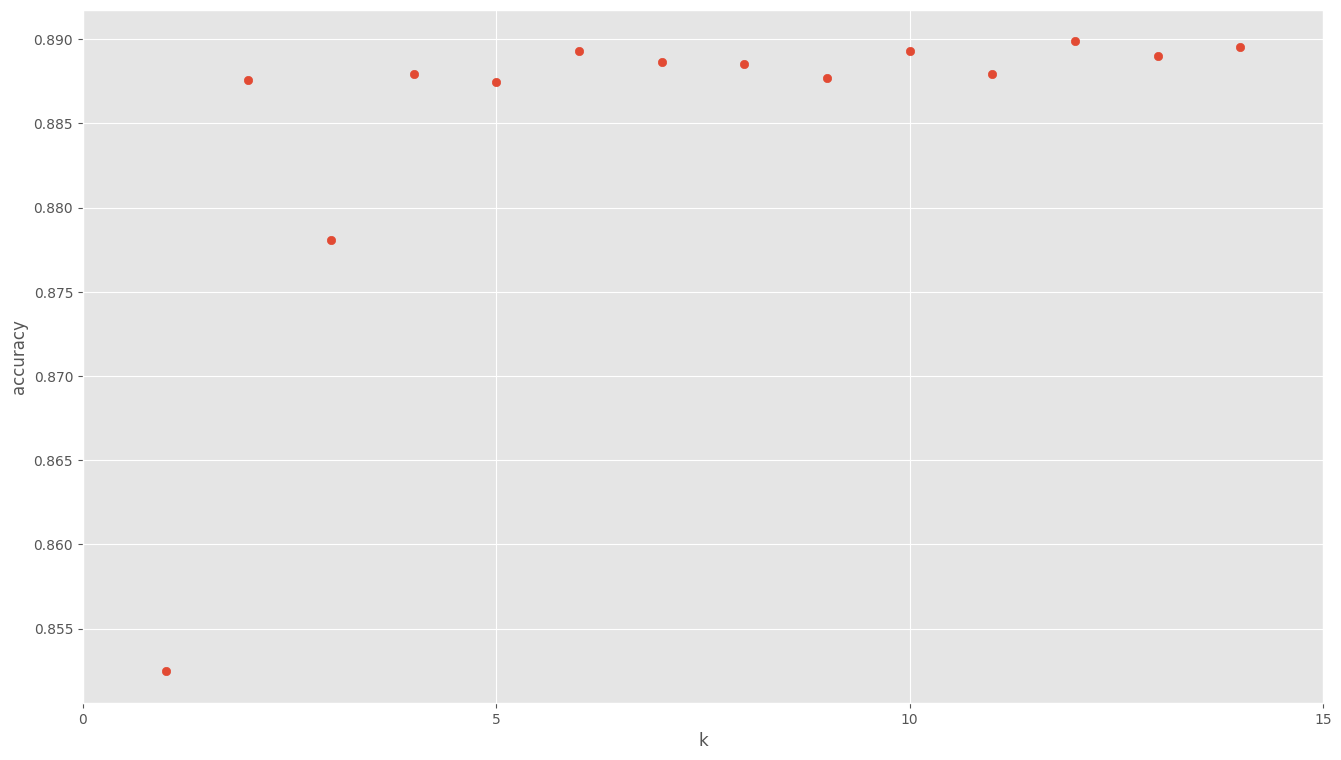

In [241]:
k_range = range(1, 15)
scores = []
for k in k_range:
      knn = KNeighborsClassifier(n_neighbors = k)
      knn.fit(X_train, y_train)
      scores.append(knn.score(X_test, y_test))
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15])

In [242]:
n_neighbors = 6 # busca los 6 mas cercanos

knn = KNeighborsClassifier(n_neighbors)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### LogisticRegression

In [243]:
clf = LogisticRegression(
    class_weight='balanced', 
    random_state=42

)

In [244]:
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

#### Decison Tree

Creación del modelo de Árboles de decisión

In [245]:
tree_clf = DecisionTreeClassifier(
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)

In [246]:
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [247]:
features = [
    col for col in credit_test.columns 
    if col not in cols_to_drop
]

target = ['No Crédito', 'Crédito']

export_graphviz(
    tree_clf,
    out_file='../data/processed/credit_tree.dot',
    feature_names=features,
    class_names=target,
    rounded=True,
    filled=True
)


In [248]:
! dot -Tpng ../data/processed/credit_tree.dot -o ../data/processed/credit_tree.png

Y este es el resultado:

![Resultado](../data/processed/credit_tree.png)

#### RandomForestClassifier

In [249]:
crf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  
    max_depth=10,
    random_state=2
)

In [ ]:
crf.fit(X_train, y_train)

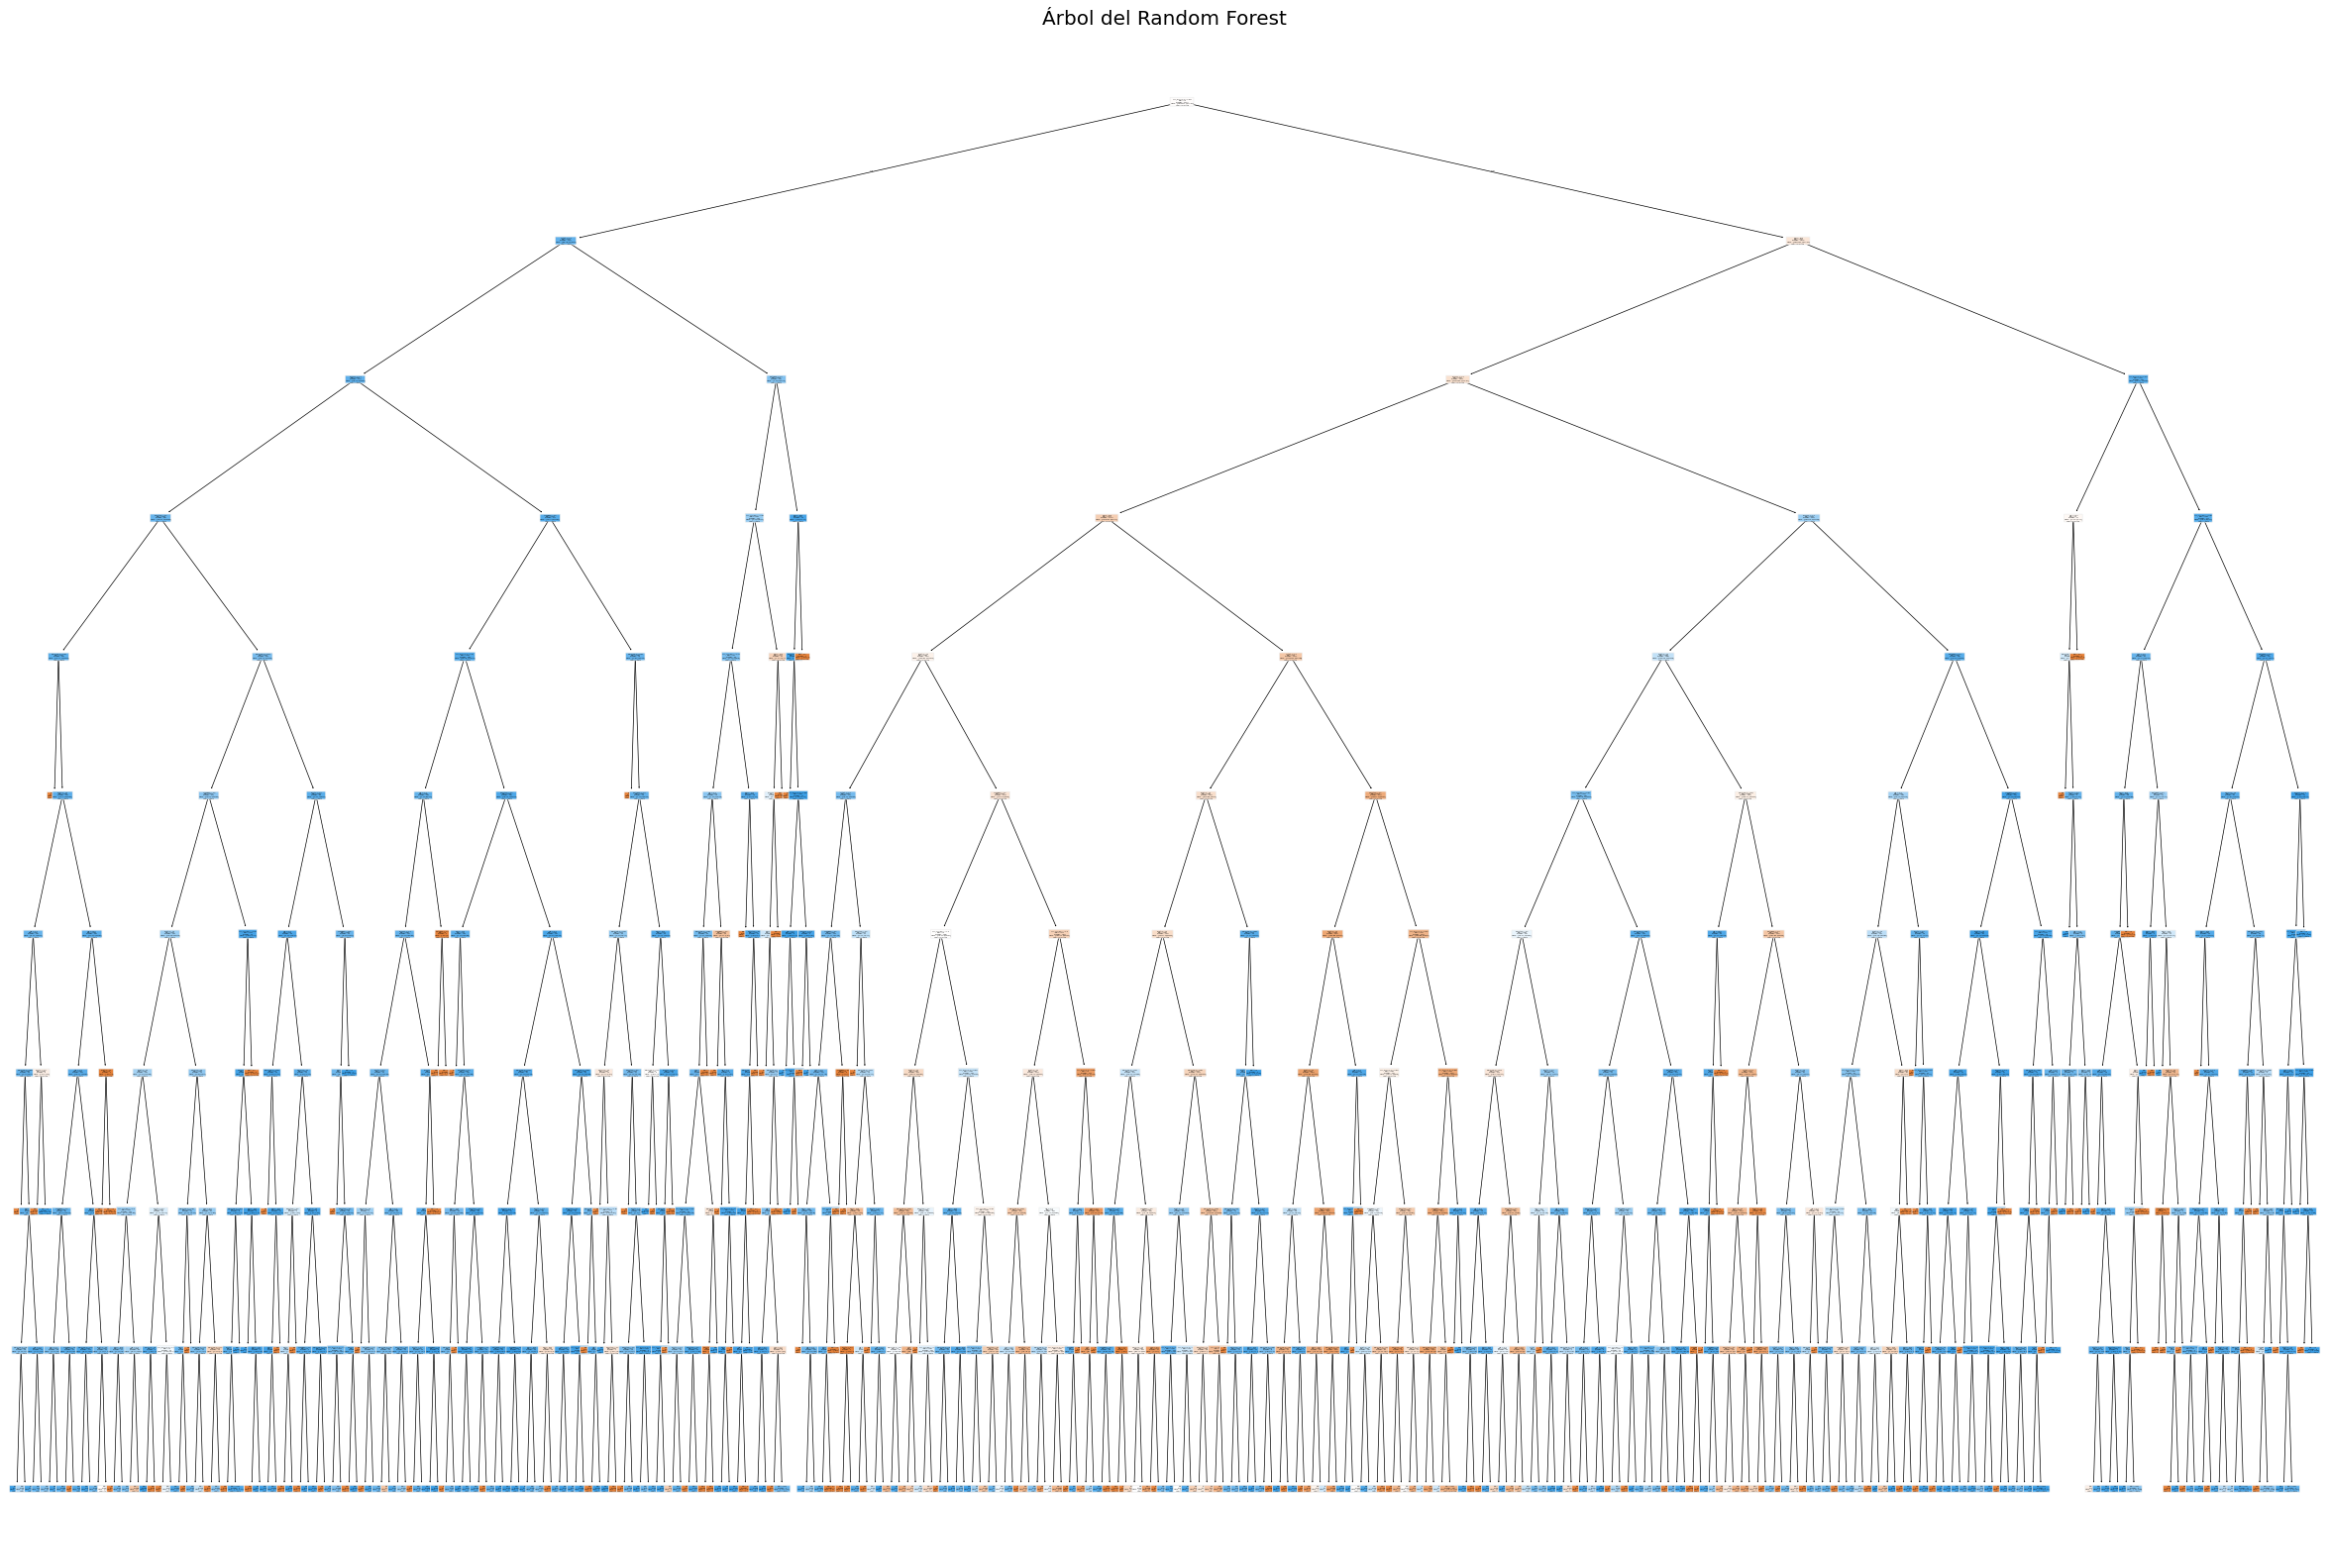

In [ ]:
plt.figure(figsize=(30, 20))
plot_tree(
    crf.estimators_[0],
    feature_names=features,
    class_names=target,
    filled=True,
    impurity=True,
    rounded=True
)
plt.title('Árbol del Random Forest')
plt.show()

#### SVM

In [ ]:
svm = make_pipeline(
    StandardScaler(), 
    SVC(
        kernel='rbf',             
        class_weight='balanced',  
        C=1.0,                    
        gamma='scale',            
        probability=True,         
        random_state=42
    )
)

In [ ]:
svm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


## 6. Análisis de resultados

#### Knn

In [ ]:
print('Accuracy of K-NN classifier on training set: {:.2f}'
      .format(knn.score(X_train, y_train)))#dice el resultado de el entreanmiento de knn
print('Accuracy of K-NN classifier on test set: {:.2f}'
      .format(knn.score(X_test, y_test)))#dice el resultado de el test de knn, si es ligeramente menor es que es bueno. si es malo tiene overfiting

Accuracy of K-NN classifier on training set: 0.91
Accuracy of K-NN classifier on test set: 0.89


#### LogisticRegression

In [ ]:
# Umbral para la decisión
prob_th = 0.7
prob_df=pd.DataFrame(clf.predict_proba(X_test[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_th).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.321191,0.678809,0
1,0.215870,0.784130,1
2,0.663380,0.336620,0
3,0.586955,0.413045,0
4,0.659621,0.340379,0
5,0.368571,0.631429,0
6,0.593445,0.406555,0
7,0.763810,0.236190,0
8,0.248666,0.751334,1
9,0.748614,0.251386,0


In [ ]:
print('Accuracy of Logistic Regresion classifier on training set: {:.2f}'
      .format(clf.score(X_train, y_train)))#dice el resultado de el entreanmiento de knn
print('Accuracy of Logistic Regresion classifier on test set: {:.2f}'
      .format(clf.score(X_test, y_test)))#dice el resultado de el test de knn, si es ligeramente menor es que es bueno. si es malo tiene overfiting

Accuracy of Logistic Regresion classifier on training set: 0.75
Accuracy of Logistic Regresion classifier on test set: 0.76


#### Decision Tree

In [ ]:
# Umbral para la decisión
prob_th = 0.7
prob_df=pd.DataFrame(tree_clf.predict_proba(X_test[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_th).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.182752,0.817248,1
1,0.187088,0.812912,1
2,0.740035,0.259965,0
3,0.740035,0.259965,0
4,0.740035,0.259965,0
5,0.597512,0.402488,0
6,0.653415,0.346585,0
7,0.825933,0.174067,0
8,0.163855,0.836145,1
9,0.754539,0.245461,0


In [ ]:
print('Score: {}'.format(tree_clf.score(X_test, y_test)))
print('Accuracy of Decision tree classifier on training set: {:.2f}'.format(tree_clf.score(X_train, y_train)))
print('Accuracy of Decision tree classifier on test set: {:.2f}'.format(tree_clf.score(X_test, y_test)))

Score: 0.8313501699854298
Accuracy of Decision tree classifier on training set: 0.83
Accuracy of Decision tree classifier on test set: 0.83


#### RandomForestClassifier

In [ ]:
print('Score: {}'.format(crf.score(X_test, y_test)))
print("Precisión en conjunto de datos de entrenamiento: {:.3f}".format(crf.score(X_train, y_train)))
print("Precisión en el conjunto de datos de evaluación: {:.3f}".format(crf.score(X_test, y_test)))

Score: 0.8576979116075765
Precisión en conjunto de datos de entrenamiento: 0.870
Precisión en el conjunto de datos de evaluación: 0.858


#### SVM

In [ ]:
print('Score: {}'.format(svm.score(X_test, y_test)))
print("Precisión en conjunto de datos de entrenamiento: {:.3f}".format(svm.score(X_train, y_train)))
print("Precisión en el conjunto de datos de evaluación: {:.3f}".format(svm.score(X_test, y_test)))

Score: 0.8443419135502671
Precisión en conjunto de datos de entrenamiento: 0.848
Precisión en el conjunto de datos de evaluación: 0.844


## 7. Realización de predicciones

#### Knn

In [ ]:
pred = knn.predict(X_test)
print(confusion_matrix(y_test, pred))

[[7166  142]
 [ 770  158]]


In [ ]:
print(classification_report(y_test, knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7308
           1       0.53      0.17      0.26       928

    accuracy                           0.89      8236
   macro avg       0.71      0.58      0.60      8236
weighted avg       0.86      0.89      0.86      8236



In [ ]:
print('Score: {}'.format(knn.score(X_test, y_test)))

Score: 0.8892666342884895


In [ ]:
probas = knn.predict_proba(credit_test)[:, 1]
predicciones_knn = (probas >= 0.7).astype(int)
predicciones_knn

array([0, 0, 0, ..., 0, 0, 0], shape=(4119,))

In [ ]:
pd.Series(predicciones_knn).value_counts()

0    4068
1      51
Name: count, dtype: int64

#### LogisticRegression

In [ ]:
print(confusion_matrix(y_test, (clf.predict_proba(X_test)[:, 1] >= 0.6).astype(int))) # si la probabilidad es mayor a a 0.6 devuelve True o False.

[[6071 1237]
 [ 369  559]]


In [ ]:
print(classification_report(y_test, (clf.predict_proba(X_test)[:, 1] >= 0.6).astype(int)))

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      7308
           1       0.31      0.60      0.41       928

    accuracy                           0.81      8236
   macro avg       0.63      0.72      0.65      8236
weighted avg       0.87      0.81      0.83      8236



In [ ]:
print('Score: {}'.format(clf.score(X_test, y_test)))

Score: 0.7565565808644973


In [ ]:
probas = clf.predict_proba(credit_test)[:, 1]
predicciones_clf = (probas >= 0.7).astype(int)
predicciones_clf

array([0, 0, 0, ..., 0, 0, 0], shape=(4119,))

In [ ]:
pd.Series(predicciones_clf).value_counts()

0    3698
1     421
Name: count, dtype: int64

#### Decision Tree

In [ ]:
print(confusion_matrix(y_test, (tree_clf.predict_proba(X_test)[:, 1] >= 0.7).astype(int))) # si la probabilidad es mayor a a 0.7 devuelve True o False.

[[6721  587]
 [ 446  482]]


In [ ]:
print(classification_report(y_test, (tree_clf.predict_proba(X_test)[:, 1] >= 0.7).astype(int)))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7308
           1       0.45      0.52      0.48       928

    accuracy                           0.87      8236
   macro avg       0.69      0.72      0.71      8236
weighted avg       0.88      0.87      0.88      8236



In [ ]:
print('Score: {}'.format(tree_clf.score(X_test, y_test)))

Score: 0.8313501699854298


In [ ]:
probas = tree_clf.predict_proba(credit_test)[:, 1]
predicciones_tree_clf = (probas >= 0.7).astype(int)
predicciones_tree_clf

array([0, 0, 0, ..., 1, 0, 0], shape=(4119,))

In [ ]:
pd.Series(predicciones_tree_clf).value_counts()

0    3568
1     551
Name: count, dtype: int64

#### RandomForestClassifier

In [ ]:
print(confusion_matrix(y_test, crf.predict(X_test)))

[[6515  793]
 [ 379  549]]


In [ ]:
print(classification_report(y_test, crf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7308
           1       0.41      0.59      0.48       928

    accuracy                           0.86      8236
   macro avg       0.68      0.74      0.70      8236
weighted avg       0.88      0.86      0.87      8236



In [ ]:
probas = crf.predict_proba(credit_test)[:, 1]
predicciones_crf = (probas >= 0.7).astype(int)
predicciones_crf

array([0, 0, 0, ..., 0, 0, 0], shape=(4119,))

In [ ]:
pd.Series(predicciones_crf).value_counts()

0    3691
1     428
Name: count, dtype: int64

#### SVM

In [ ]:
print(confusion_matrix(y_test, svm.predict(X_test)))

[[6402  906]
 [ 376  552]]


In [ ]:
print(classification_report(y_test, svm.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      7308
           1       0.38      0.59      0.46       928

    accuracy                           0.84      8236
   macro avg       0.66      0.74      0.69      8236
weighted avg       0.88      0.84      0.86      8236



In [ ]:
probas = svm.predict_proba(credit_test)[:, 1]
predicciones_svm = (probas >= 0.4).astype(int)
predicciones_svm

array([0, 0, 0, ..., 0, 0, 0], shape=(4119,))

In [ ]:
pd.Series(predicciones_svm).value_counts()

0    3706
1     413
Name: count, dtype: int64

## 8. Visualización

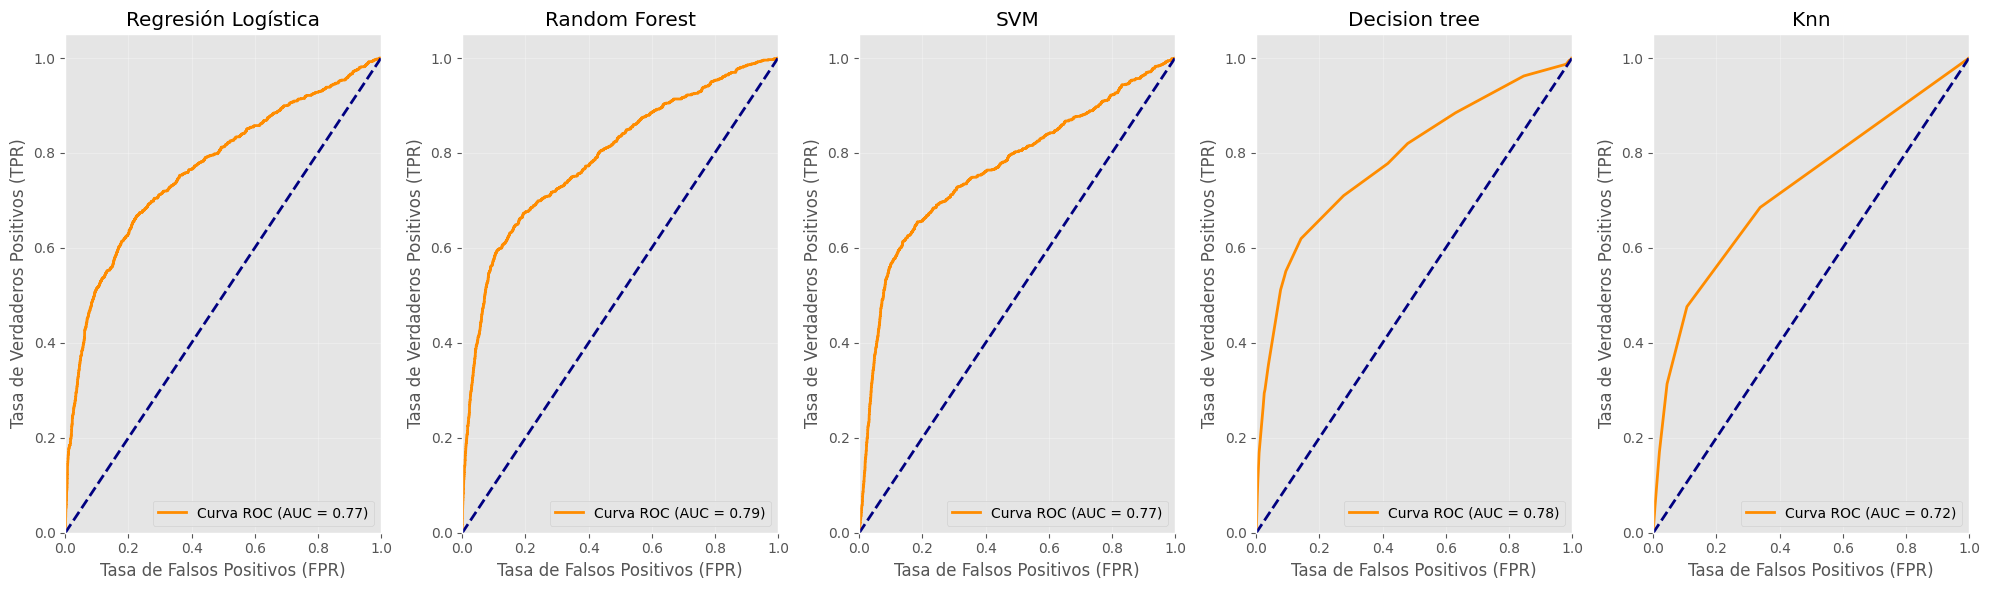

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

models = [
    ('Regresión Logística', clf),
    ('Random Forest', crf),
    ('SVM', svm),
    ('Decision tree', tree_clf),
    ('Knn', knn),
]

for ax, (nombre, modelo) in zip(axes, models):
    
    y_probs = modelo.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea base aleatoria
    
    # Decoración del gráfico
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'{nombre}')
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Esta visualización cierra el debate. El Random Forest no solo tiene mejor equilibrio F1-Score (como vimos en las tablas), sino que domina matemáticamente el espacio de probabilidades (como vemos en esta curva ROC).

ValueError: El modelo Knn no permite calcular importancias

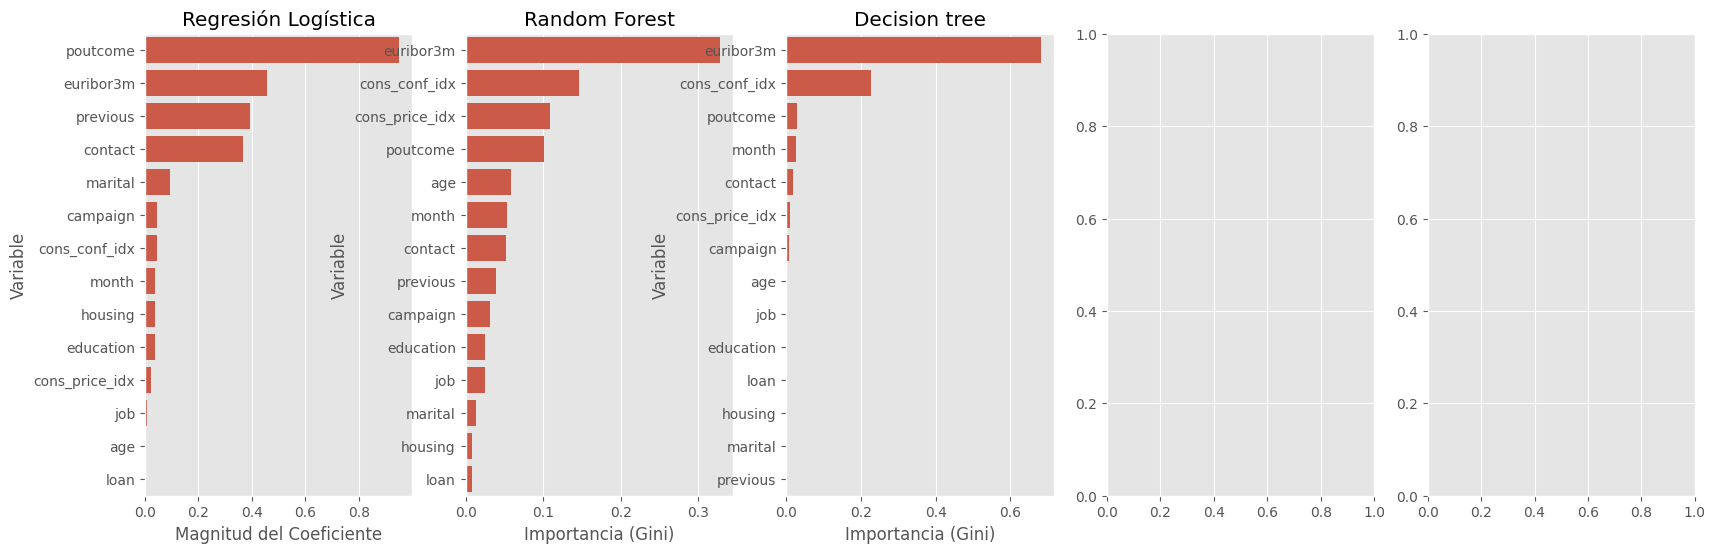

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

models = [
    ('Regresión Logística', clf),
    ('Random Forest', crf),
    ('Decision tree', tree_clf),
    ('Knn', knn),
    ('SVM', svm),
]

feature_names = X.columns

for ax, (nombre, modelo) in zip(axes, models):

    # Random Forest
    if hasattr(modelo, 'feature_importances_'):
        importances = modelo.feature_importances_
        xlabel = 'Importancia (Gini)'

    # Regresión Logística y SVM lineal
    elif hasattr(modelo, 'coef_'):
        importances = np.abs(modelo.coef_[0])
        xlabel = 'Magnitud del Coeficiente'

    else:
        raise ValueError(f'El modelo {nombre} no permite calcular importancias')

    feature_imp_df = (
        pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        })
        .sort_values(by='Importance', ascending=False)
    )

    sns.barplot(
        x='Importance',
        y='Feature',
        data=feature_imp_df,
        ax=ax
    )

    ax.set_title(nombre)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Variable')

plt.tight_layout()
plt.show()

Regresión Logística (Enfoque en el Pasado): Este modelo depende casi exclusivamente de la variable poutcome (resultado de la campaña de marketing anterior). Asume una relación lineal fuerte: "Si el cliente aceptó antes, aceptará ahora". Esto puede ser riesgoso si las condiciones del mercado cambian.

Random Forest (Enfoque en el Entorno): Prioriza variables económicas externas como euribor3m (tasas de interés), cons_conf_idx (confianza del consumidor) y cons_price_idx (IPC). Este modelo sugiere que la decisión del cliente depende más de la situación económica actual que de su historial pasado

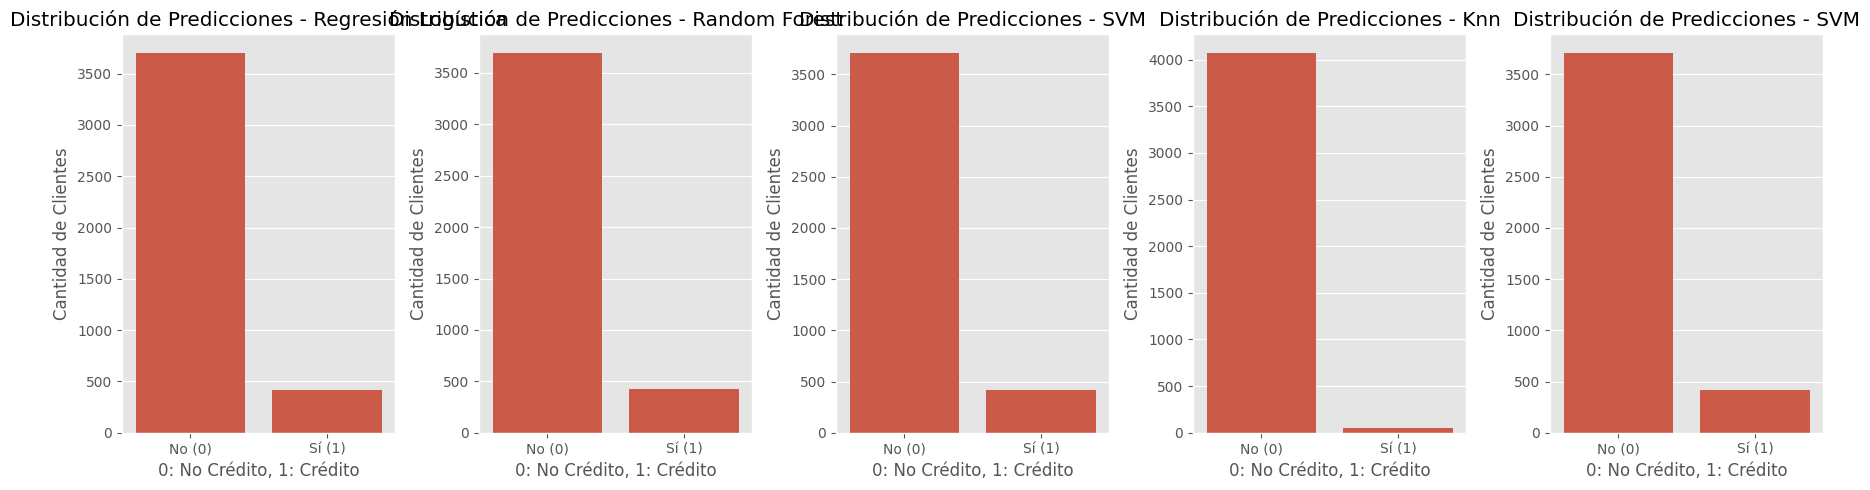

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

predicciones = [
    ('Regresión Logística', predicciones_clf),
    ('Random Forest', predicciones_crf),
    ('SVM', predicciones_svm),
    ('Knn', predicciones_knn),
    ('SVM', predicciones_svm),
]

for ax, (nombre, preds) in zip(axes, predicciones):

    sns.countplot(x=preds, ax=ax)

    ax.set_title(f'Distribución de Predicciones - {nombre}')
    ax.set_xlabel('0: No Crédito, 1: Crédito')
    ax.set_ylabel('Cantidad de Clientes')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.show()


Ante la duda, el modelo dice NO. Para que la barra naranja suba, el modelo tiene que estar muy seguro. No se la juega.

## 9. Conclusiones

## Conclusiones Individuales

### 1. KNN (K-Nearest Neighbors) - *El Tímido*
* **Conclusión:** Es el **peor modelo** para este caso.
* **Por qué:** Al basarse en distancias, la mayoría de clase 0 "ahoga" a los pocos casos de clase 1.
* **Resultado:** Tiene un Recall pésimo (0.17). Deja escapar el 83% de los casos que te interesan. No es útil para detectar eventos poco frecuentes.

### 2. Logistic Regression - *El Paranoico*
* **Conclusión:** Es el modelo más **agresivo**, ideal si no toleras perder ni un solo caso, pero costoso de operar.
* **Por qué:** Tiene el **Recall más alto (0.62)**. Encuentra más positivos que nadie (575).
* **El precio:** Su precisión es muy baja (0.31). Genera una cantidad masiva de ruido (1279 falsas alarmas). Es como una red de pesca gigante: atrapa el pez que quieres, pero también mucha basura.

### 3. Decision Tree - *El Punto Medio*
* **Conclusión:** Un modelo decente, pero superado por su "hermano mayor" (Random Forest).
* **Por qué:** Tiene métricas equilibradas, pero los árboles simples tienden a ser inestables. Detecta menos casos (471) que el Random Forest (549) con una precisión similar. No hay razón para usarlo si tienes Random Forest disponible.

### 4. SVM (Support Vector Machine) - *El Subcampeón Lento*
* **Conclusión:** Muy potente detectando (Recall 0.60), casi igualando a la Regresión Logística, pero con mejor precisión.
* **Desventaja:** Computacionalmente es pesado y lento. Aunque sus resultados son buenos, el Random Forest logra un mejor equilibrio general en menos tiempo de entrenamiento.

### 5. Random Forest - *El Equilibrado (Campeón)*
* **Conclusión:** Es el modelo **más robusto y equilibrado** de la prueba.
* **Por qué:**
    * Tiene el mejor **F1-Score (0.49)**.
    * Mantiene un Recall alto (0.59), muy cerca de los líderes agresivos.
    * Mantiene una Precisión aceptable (0.41), reduciendo las falsas alarmas significativamente comparado con Logistic Reg. o SVM.